**Debugging AI Agent in Langsmith**

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

#state graph
from langgraph.graph import StateGraph , START , END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode , tools_condition

from langchain_core.tools import tool
from langchain_core.messages import BaseMessage

from langchain_groq import ChatGroq

import os 
from dotenv import load_dotenv
load_dotenv(override=True)

os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY']=os.getenv('LANGCHAIN_API_KEY')
os.environ['LANGSMITH_TRACING']="TRUE"
os.environ['LANGSMITH_PROJECT']="Debugging_AI_AGENT"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"



llm = ChatGroq(
    model="openai/gpt-oss-20b"
)

In [2]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

print("LANGSMITH_TRACING:", os.getenv("LANGSMITH_TRACING"))
print("LANGSMITH_API_KEY:", bool(os.getenv("LANGSMITH_API_KEY")))
print("LANGSMITH_PROJECT:", os.getenv("LANGSMITH_PROJECT"))
print("LANGSMITH_ENDPOINT:", os.getenv("LANGSMITH_ENDPOINT"))

LANGSMITH_TRACING: true
LANGSMITH_API_KEY: True
LANGSMITH_PROJECT: Debugging_AI_AGENT
LANGSMITH_ENDPOINT: https://api.smith.langchain.com


Step-2 Tool

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

@tool
def add(a:float, b:float):
    """Add two number"""
    return a + b

tool_node = ToolNode([add])

llm_with_tools = llm.bind_tools([add])

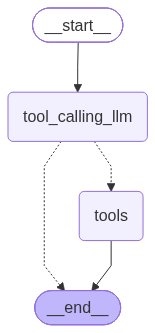

In [4]:
#state graph
from langgraph.graph import StateGraph , START , END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode , tools_condition

#node defination
def call_llm_model(state: State):
    return {"messages": [llm_with_tools.invoke(state['messages'])]}

#Graph
graph_builder = StateGraph(State)

#adding nodes
graph_builder.add_node("tool_calling_llm", call_llm_model)
graph_builder.add_node("tools", tool_node)

#adding edges
graph_builder.add_edge(START, "tool_calling_llm")
graph_builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message from assistant is a tool call->tools_condtion routes to tools
    # if the latest message from assistant isn't a tool call->tools_condtion routes to End
    tools_condition,
)
graph_builder.add_edge("tools",END )

graph = graph_builder.compile()
graph

In [5]:
response=graph.invoke({'messages':"is there any direct flight from india to moscow ?"})
response

{'messages': [HumanMessage(content='is there any direct flight from india to moscow ?', additional_kwargs={}, response_metadata={}, id='4c9a320e-32c1-434d-a1b6-53d7b1089c6d'),
  AIMessage(content='**Short answer:**  \nYes – there are direct flights from India to Moscow (mostly to Moscow‑Sheremetyevo, sometimes to Domodedovo). The main carriers that currently operate nonstop services are:\n\n| Airline | Typical departure city in India | Frequency (as of 2024‑2025) | Notes |\n|---------|---------------------------------|-----------------------------|-------|\n| **Air India** | Delhi (IND) | Daily (or 6‑7 times a week) | Main hub, 7–8\u202fh flight |\n| **Air India** | Bangalore (BLR) | Daily (or 6‑7 times a week) | 7–8\u202fh flight |\n| **Aeroflot** | Delhi (IND) | 3–4 times a week | Operates on Air India‑codeshare basis |\n| **Aeroflot** | Mumbai (BOM) | 2–3 times a week | |\n| **Air India Express** | – | *No* direct service to Moscow (only connecting flights) | |\n| **Other carriers**

In [ ]:
response=graph.invoke({'messages':"what is 2 plus 7 ?"})
response

{'messages': [HumanMessage(content='what is 2 plus 7 ?', additional_kwargs={}, response_metadata={}, id='46cf093a-eaac-41f7-a810-3c3ebd911f2b'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "what is 2 plus 7 ?" Need to compute 2+7=9. But they provided a tool to add two numbers. We should use the function.', 'tool_calls': [{'id': 'fc_c7f5d7a5-d973-485d-8101-7441c0948602', 'function': {'arguments': '{"a":2,"b":7}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 128, 'total_tokens': 193, 'completion_time': 0.074114532, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.006253917, 'prompt_tokens_details': None, 'queue_time': 0.31161426, 'total_time': 0.080368449}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4f7e7dc26e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a08b46-49b7-7912

In [ ]:
# from langsmith import Client

# client = Client()

# print("LangSmith client created successfully")
# print(list(client.list_projects()))

LangSmith client created successfully
[TracerSessionResult(id=UUID('d1872bd5-dfb8-43e5-a859-c78c1a7a6b68'), start_time=datetime.datetime(2026, 9, 10, 12, 7, 7, 376062, tzinfo=TzInfo(0)), end_time=None, description=None, name='Debugging_AI_AGENT', extra=None, tenant_id=UUID('11b40d47-d832-42d6-905b-8629f8c14fc1'), reference_dataset_id=None, run_count=None, latency_p50=None, latency_p99=None, total_tokens=None, prompt_tokens=None, completion_tokens=None, last_run_start_time=datetime.datetime(2026, 9, 10, 12, 23, 56, 273806, tzinfo=TzInfo(0)), feedback_stats=None, session_feedback_stats=None, run_facets=None, total_cost=None, prompt_cost=None, completion_cost=None, first_token_p50=None, first_token_p99=None, error_rate=None), TracerSessionResult(id=UUID('9316b463-3aa7-4a2b-b886-4e40ae55be56'), start_time=datetime.datetime(2026, 4, 17, 5, 31, 3, 702777, tzinfo=TzInfo(0)), end_time=None, description=None, name='RAG_PRACTICE', extra=None, tenant_id=UUID('11b40d47-d832-42d6-905b-8629f8c14fc1'

In [8]:
# import os
# from langsmith import tracing_context

# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_PROJECT"] = "Debugging_AI_AGENT"
# os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

# with tracing_context(
#     project_name="Debugging_AI_AGENT",
#     enabled=True
# ):
#     response = llm.invoke("This is a LangSmith tracing test.")

# print(response.content)